# Resumen de Procesamiento y Modelado de Datos

In [ ]:
import pandas as pd
import numpy as np
import random
import re
import joblib
from sklearn.model_selection import train_test_split
from sklearn.feature_extraction.text import TfidfVectorizer
from sklearn.linear_model import LogisticRegression
from sklearn.ensemble import RandomForestClassifier
from sklearn.metrics import classification_report, confusion_matrix
from sklearn.preprocessing import LabelEncoder, StandardScaler
import matplotlib.pyplot as plt
import seaborn as sns
import os

## 1. Generación de Datos Finales

In [ ]:
# Glosas de comercios reales, ahora con mayor ambigüedad y solapamiento intencional
# Algunos términos son deliberadamente compartidos entre categorías para introducir confusión
plantillas_reales = {
    "Alimentación": ["JUMBO BILBAO", "LIDER EXPRESS", "MCDONALDS WEB", "ALMACEN VECINAL", "PRONTO COPEC", "PEDIDOSYA CL", "VERDULERIA DON PEPE", "MERCADO CENTRAL", "TIENDA ONLINE", "SUPERMERCADO DIA", "DELIVERY COMIDA"],
    "Transporte": ["COPEC SANTIAGO", "SHELL RUTA 5", "UBER TRIP", "DIDI RIDE", "CARGA BIP WEB", "AUTOPISTA CENTRAL", "TAXI APP", "ESTACIONAMIENTO", "PEAJE TAG", "GASOLINERA"],
    "Salud": ["CRUZ VERDE LOCAL", "FARMACIA AHUMADA", "CLINICA INDISA", "INTEGRAMEDICA", "EXAMENES MED", "CONSULTA ESPECIALISTA", "CENTRO MEDICO", "OPTICA VISION"],
    "Vivienda": ["SODIMAC HOME", "EASY PORTAL", "CONDOMINIO GGCC", "ARRIENDO DEPT", "PINTURAS SHERWIN", "REPARACIONES HOGAR", "SERVICIOS GENERALES", "PAGO CUOTAS", "HOME CENTER"],
    "Educación": ["UDEMY COURSES", "COLEGIO MENSUALIDAD", "MATRICULA UNIV", "SISTEMA DUOC", "LIBRERIA UNIVERSITARIA", "PLATAFORMA APRENDIZAJE", "PAGO CUOTAS", "CURSO IDIOMAS", "TIENDA ONLINE"],
    "Ocio": ["NETFLIX.COM", "SPOTIFY PREMIUM", "CINEMARK ONLINE", "STEAM GAMES", "BAR LA ESQUINA", "RESTAURANT FANCY", "TIENDA ONLINE", "EVENTO DEPORTIVO", "MERCADO CENTRAL", "COMPRA EN AMAZON", "ENTRETENIMIENTO PLUS"],
    "Servicios": ["ENEL DISTRIBUCION", "AGUAS ANDINAS", "VTR BANDA ANCHA", "GASCO LIQUADO", "CLARO TELECOM", "SERVICIO TECNICO", "TALLER AUTOMOTRIZ", "SERVICIOS GENERALES", "PAGO CUOTAS", "TIENDA ONLINE", "BANCO DEL ESTADO"]
}

# Prefijos transaccionales que el banco sí incluye en la glosa de texto
prefijos_banco = ["COMPRA TBK", "TEF ENVIADA", "CARGO TC", "PAGO AUTOMATICO", "PAGO WEB", "DEBITO", "ABONO"]

# Función para simular errores tipográficos ocasionales
def simular_typo(texto, prob_typo=0.05):
    if random.random() < prob_typo:
        # Reemplaza caracteres aleatorios con números o caracteres similares para simular typos
        char_map = {'a': '4', 'e': '3', 'i': '1', 'o': '0', 's': '5', 'l': '1', 'b': '8'}
        mod_texto = list(texto)
        num_cambios = random.randint(1, min(3, len(texto) // 2)) # Hasta 3 cambios o la mitad de la palabra
        for _ in range(num_cambios):
            idx = random.randint(0, len(mod_texto) - 1)
            original_char = mod_texto[idx]
            if original_char.lower() in char_map:
                mod_texto[idx] = char_map[original_char.lower()] if random.random() < 0.7 else original_char.swapcase()
            elif original_char.isalpha():
                mod_texto[idx] = original_char.swapcase()
        return "".join(mod_texto)
    return texto

def generar_dataset_altamente_estructurado_y_ambiguo(num_registros=7000, semilla=42):
    random.seed(semilla)
    datos = []

    for i in range(num_registros):
        cat = random.choice(categorias)

        comercio = random.choice(plantillas_reales[cat])
        prefijo = random.choice(prefijos_banco)

        descripcion_glosa = f"{prefijo} {comercio}"

        # Aplicar typos ocasionales a la glosa
        descripcion_glosa = simular_typo(descripcion_glosa)

        codigo_auth = f"{random.randint(10000000, 99999999)}"

        # Montos (se mantiene la lógica de montos por categoría)
        if cat == "Vivienda": monto = round(random.uniform(50, 400), 2)
        elif cat in ["Alimentación", "Ocio", "Transporte"]: monto = round(random.uniform(5, 60), 2)
        else: monto = round(random.uniform(10, 150), 2)

        datos.append({
            "id_interno": i + 1,
            "codigo_autorizacion": codigo_auth,
            "descripcion": descripcion_glosa,
            "valor": monto,
            "categoria": cat # La categoría real es la principal generada
        })

    return pd.DataFrame(datos)

categorias = ["Alimentación", "Transporte", "Salud", "Vivienda", "Educación", "Ocio", "Servicios"]
df_transacciones = generar_dataset_altamente_estructurado_y_ambiguo(7000, semilla=42)
print("--- Dataset de Transacciones Altamente Ambiguo Generado ---")
print(df_transacciones.head(5))

--- Dataset de Transacciones Altamente Ambiguo Generado ---
   id_interno codigo_autorizacion                 descripcion   valor  \
0           1            42868828  COMPRA TBK SPOTIFY PREMIUM   17.28   
1           2            83197857      DEBITO SPOTIFY PREMIUM    9.78   
2           3            41227216     COMPRA TBK SODIMAC HOME  226.87   
3           4            83140807   TEF ENVIADA TIENDA ONLINE   28.07   
4           5            31429110      ABONO PINTURAS SHERWIN  294.35   

      categoria  
0          Ocio  
1          Ocio  
2      Vivienda  
3  Alimentación  
4      Vivienda  


In [ ]:
def generar_perfiles_volatiles(num_perfiles=5000, semilla=42):
    random.seed(semilla)
    np.random.seed(semilla)

    perfiles = []

    for i in range(num_perfiles):
        # 1. Simular variables base usando distribuciones más realistas
        ingreso = round(np.random.normal(3500, 1500))
        ingreso = max(800, min(ingreso, 9000)) # Forzar límites realistas

        # Nivel de endeudamiento centrado en el 30% (promedio saludable/observación)
        nivel_endeudamiento = np.random.normal(30, 15)
        nivel_endeudamiento = round(max(0, min(nivel_endeudamiento, 85)), 1)

        frecuencia_ahorro = random.choice(["Baja", "Media", "Alta"])

        # Gasto mensual centrado en el 75% del ingreso
        ratio_gasto = np.random.normal(0.75, 0.18)
        ratio_gasto = max(0.25, min(ratio_gasto, 1.3)) # Desde 25% hasta 130% de sobregiro
        gasto_total = round(ingreso * ratio_gasto, 2)

        # Mapeo numérico interno de la conducta de ahorro para la ecuación
        ahorro_val = {"Baja": 0, "Media": 1, "Alta": 2}[frecuencia_ahorro]

        # 2. ECUACIÓN DE NEGOCIO BASE (Lógica financiera pura)
        # El score base sube con la deuda y el gasto, y baja con el ahorro
        score_base = (nivel_endeudamiento * 0.5) + (ratio_gasto * 40) - (ahorro_val * 12)

        # 3. INYECCIÓN DEL RUIDO SANO (Choque Estocástico / Variable No Observada)
        # Una distribución normal con desviación estándar de 10 introduce imprevistos del mundo real.
        # Esto genera los "traslapes" lógicos de los que hablamos.
        choque_imprevisto = np.random.normal(0, 10)
        score_final = score_base + choque_imprevisto

        # 4. Asignación estricta del perfil según el Score Final con Choque incluido
        if score_final >= 52:
            perfil = "En riesgo"
        elif score_final >= 22:
            perfil = "En observación"
        else:
            perfil = "Saludable"

        perfiles.append({
            "id_usuario": i + 1,
            "ingreso_mensual": ingreso,
            "nivel_endeudamiento": nivel_endeudamiento,
            "frecuencia_ahorro": frecuencia_ahorro,
            "gasto_total": gasto_total,
            "ratio_gasto_ingreso": round(ratio_gasto, 2),
            "perfil_financiero": perfil
        })

    return pd.DataFrame(perfiles)

df_perfiles_volatiles = generar_perfiles_volatiles(5000, semilla=42)
print("\n--- Dataset de Perfiles Financieros con Volatilidad Conductual Generado ---")
print(df_perfiles_volatiles.head(5))


--- Dataset de Perfiles Financieros con Volatilidad Conductual Generado ---
   id_usuario  ingreso_mensual  nivel_endeudamiento frecuencia_ahorro  \
0           1             4245                 27.9              Alta   
1           2             3149                 26.5              Baja   
2           3             2796                 38.1              Baja   
3           4             3863                  1.3              Alta   
4           5             1981                 34.7             Media   

   gasto_total  ratio_gasto_ingreso perfil_financiero  
0      3678.65                 0.87    En observación  
1      3256.88                 1.03         En riesgo  
2      1863.77                 0.67    En observación  
3      1697.85                 0.44         Saludable  
4      1161.97                 0.59         Saludable  


## 2. Preprocesamiento NLP y Entrenamiento del Modelo de Transacciones

In [ ]:
# Limpieza básica de texto (la misma función, ya que el preprocesamiento debe ser consistente)
def limpiar_texto(texto):
    texto = texto.lower() # Convertir a minúsculas
    texto = re.sub(r'[^a-záéíóúñ\s]', '', texto) # Remover caracteres especiales y números (para enfocarse en el texto)
    return texto

df_transacciones['desc_limpia'] = df_transacciones['descripcion'].apply(limpiar_texto)

# Dividir datos en conjuntos de Entrenamiento y Testeo (80-20)
X_train, X_test, y_train, y_test = train_test_split(
    df_transacciones['desc_limpia'], # Usamos la columna limpia de la descripción
    df_transacciones['categoria'],
    test_size=0.2,
    random_state=42,
    stratify=df_transacciones['categoria'] # Mantiene las clases balanceadas en ambos sets
)

# Convertir el texto a vectores numéricos usando TF-IDF
# Es crucial re-inicializar el vectorizador para que aprenda del nuevo vocabulario ambiguo
vectorizador = TfidfVectorizer(ngram_range=(1, 2))
X_train_tfidf = vectorizador.fit_transform(X_train)
X_test_tfidf = vectorizador.transform(X_test)

# Entrenar un clasificador rápido de alto rendimiento (Regresión Logística)
modelo_clasificador = LogisticRegression(max_iter=1000)
modelo_clasificador.fit(X_train_tfidf, y_train)

y_pred = modelo_clasificador.predict(X_test_tfidf)
print("\n--- INFORME DE RENDIMIENTO DEL MODELO DE TRANSACCIONES ---")
print(classification_report(y_test, y_pred))


--- INFORME DE RENDIMIENTO DEL MODELO DE TRANSACCIONES ---
              precision    recall  f1-score   support

Alimentación       0.89      0.87      0.88       196
   Educación       0.82      0.84      0.83       196
        Ocio       0.91      0.90      0.90       197
       Salud       1.00      1.00      1.00       202
   Servicios       0.90      0.78      0.84       204
  Transporte       1.00      1.00      1.00       200
    Vivienda       0.82      0.93      0.87       205

    accuracy                           0.90      1400
   macro avg       0.91      0.90      0.90      1400
weighted avg       0.91      0.90      0.90      1400



## 3. Preprocesamiento y Entrenamiento del Modelo de Perfiles Financieros

In [ ]:
# Codificación de Variables Categóricas (frecuencia_ahorro)
le_volatiles = LabelEncoder()
df_perfiles_volatiles['frecuencia_ahorro_encoded'] = le_volatiles.fit_transform(df_perfiles_volatiles['frecuencia_ahorro'])

# Definición de características (X) y variable objetivo (y)
X_volatiles = df_perfiles_volatiles[['ingreso_mensual', 'nivel_endeudamiento', 'frecuencia_ahorro_encoded', 'gasto_total', 'ratio_gasto_ingreso']]
y_volatiles = df_perfiles_volatiles['perfil_financiero']

# Escalado de Variables Numéricas
scaler_perfiles_volatiles = StandardScaler()
X_scaled_volatiles = scaler_perfiles_volatiles.fit_transform(X_volatiles)
X_scaled_df_volatiles = pd.DataFrame(X_scaled_volatiles, columns=X_volatiles.columns, index=X_volatiles.index)

# División del Dataset
X_train_perfiles_volatiles, X_test_perfiles_volatiles, y_train_perfiles_volatiles, y_test_perfiles_volatiles = train_test_split(
    X_scaled_df_volatiles,
    y_volatiles,
    test_size=0.2,
    random_state=42,
    stratify=y_volatiles
)

# Entrenamiento del Modelo de Clasificación (RandomForestClassifier)
modelo_perfiles_rf_volatiles = RandomForestClassifier(
    n_estimators=200,
    max_depth=7,
    class_weight='balanced',
    random_state=42,
    n_jobs=-1
)
modelo_perfiles_rf_volatiles.fit(X_train_perfiles_volatiles, y_train_perfiles_volatiles)

y_pred_rf_volatiles = modelo_perfiles_rf_volatiles.predict(X_test_perfiles_volatiles)
print("\n--- INFORME DE RENDIMIENTO DEL MODELO DE PERFILES FINANCIEROS (Random Forest) ---")
print(classification_report(y_test_perfiles_volatiles, y_pred_rf_volatiles))


--- INFORME DE RENDIMIENTO DEL MODELO DE PERFILES FINANCIEROS (Random Forest) ---
                precision    recall  f1-score   support

En observación       0.80      0.64      0.71       599
     En riesgo       0.48      0.72      0.58       134
     Saludable       0.64      0.76      0.69       267

      accuracy                           0.68      1000
     macro avg       0.64      0.71      0.66      1000
  weighted avg       0.71      0.68      0.69      1000



## 4. Serialización de Modelos y Preprocesadores

In [ ]:
# output_dir = "modelos_y_preprocesadores"
# os.makedirs(output_dir, exist_ok=True)

# print("📦 Serializando artefactos de Machine Learning...")

# joblib.dump(vectorizador, os.path.join(output_dir, 'tfidf_vectorizer.pkl'))
# print(f"Vectorizador TF-IDF guardado en: {os.path.join(output_dir, 'tfidf_vectorizer.pkl')}")

# joblib.dump(modelo_clasificador, os.path.join(output_dir, 'modelo_clasificador_transacciones.pkl'))
# print(f"Modelo de clasificador de transacciones guardado en: {os.path.join(output_dir, 'modelo_clasificador_transacciones.pkl')}")

# joblib.dump(scaler_perfiles_volatiles, os.path.join(output_dir, 'scaler_perfiles_volatiles.pkl'))
# print(f"Escalador de perfiles volátiles guardado en: {os.path.join(output_dir, 'scaler_perfiles_volatiles.pkl')}")

# joblib.dump(le_volatiles, os.path.join(output_dir, 'label_encoder_frecuencia_ahorro_volatiles.pkl'))
# print(f"LabelEncoder de frecuencia de ahorro volátiles guardado en: {os.path.join(output_dir, 'label_encoder_frecuencia_ahorro_volatiles.pkl')}")

# joblib.dump(modelo_perfiles_rf_volatiles, os.path.join(output_dir, 'modelo_clasificador_perfiles_rf_volatiles.pkl'))
# print(f"Modelo de clasificador de perfiles financieros RF volátiles guardado en: {os.path.join(output_dir, 'modelo_clasificador_perfiles_rf_volatiles.pkl')}")

# print("\n¡Todos los modelos y preprocesadores han sido serializados exitosamente!")

## 5. Prueba de Inferencia de Extremo a Extremo

In [ ]:
# output_dir = "modelos_y_preprocesadores"

# # 1. Cargar artefactos desde el disco (Como lo haría la API)
# vectorizador_loaded = joblib.load(os.path.join(output_dir, 'tfidf_vectorizer.pkl'))
# modelo_clasificador_loaded = joblib.load(os.path.join(output_dir, 'modelo_clasificador_transacciones.pkl'))

# risk_service = joblib.load(os.path.join(output_dir, 'modelo_clasificador_perfiles_rf_volatiles.pkl'))
# encoder_ahorro_service = joblib.load(os.path.join(output_dir, 'label_encoder_frecuencia_ahorro_volatiles.pkl'))
# scaler_perfiles_service = joblib.load(os.path.join(output_dir, 'scaler_perfiles_volatiles.pkl'))

# # Función de limpieza de texto (debe ser la misma usada en el entrenamiento)
# def limpiar_texto_inference(texto):
#     texto = texto.lower()
#     texto = re.sub(r'[^a-záéíóúñ\s]', '', texto)
#     return texto

# # --- PRUEBA 1: Clasificación de una Glosa de Banco (NLP) ---
# nueva_glosa = ["COMPRA TBK JUMBO BILBAO STGO"]
# nueva_glosa_limpia = limpiar_texto_inference(nueva_glosa[0])
# nueva_glosa_tfidf = vectorizador_loaded.transform([nueva_glosa_limpia])
# categoria_predicha = modelo_clasificador_loaded.predict(nueva_glosa_tfidf)[0]
# print(f"💳 Glosa recibida: '{nueva_glosa[0]}'")
# print(f"🏷️  Categoría asignada por Modelo 1: {categoria_predicha}\n")

# # --- PRUEBA 2: Evaluación de Riesgo Financiero (Random Forest) ---
# nuevo_usuario_json = {
#     "ingreso_mensual": 4200,
#     "nivel_endeudamiento": 55.0,
#     "frecuencia_ahorro": "Baja",
#     "gasto_total": 3800.0
# }

# ratio_gasto = nuevo_usuario_json["gasto_total"] / nuevo_usuario_json["ingreso_mensual"]
# ahorro_cod = encoder_ahorro_service.transform([nuevo_usuario_json["frecuencia_ahorro"]])[0]

# df_input = pd.DataFrame([{
#     'ingreso_mensual': nuevo_usuario_json["ingreso_mensual"],
#     'nivel_endeudamiento': nuevo_usuario_json["nivel_endeudamiento"],
#     'frecuencia_ahorro_encoded': ahorro_cod,
#     'gasto_total': nuevo_usuario_json["gasto_total"],
#     'ratio_gasto_ingreso': ratio_gasto
# }])

# df_input_scaled = scaler_perfiles_service.transform(df_input)
# df_input_scaled = pd.DataFrame(df_input_scaled, columns=df_input.columns)

# perfil_predicho = risk_service.predict(df_input_scaled)[0]
# probabilidades = risk_service.predict_proba(df_input_scaled)[0]

# print(f"👤 Evaluación de usuario JSON: {nuevo_usuario_json}")
# print(f"🚨 Perfil Asignado por Modelo 2: {perfil_predicho}")
# print(f"📊 Distribución de Probabilidades:")
# for clase, prob in zip(risk_service.classes_, probabilidades):
#     print(f"   - {clase}: {prob*100:.1f}%")

# Notebook Resumen: Generación y Serialización de Modelos NLP y Umbral de Confianza

In [ ]:
import pandas as pd
import numpy as np
import re
import joblib
import os

from sklearn.model_selection import train_test_split
from sklearn.feature_extraction.text import TfidfVectorizer
from sklearn.linear_model import LogisticRegression
from sklearn.base import BaseEstimator, ClassifierMixin
from sklearn.pipeline import Pipeline

## 1. Función de Limpieza de Texto

Esta función se aplicará a todas las descripciones de transacciones antes del procesamiento NLP.

In [ ]:
def limpiar_texto(texto):
    texto = texto.lower() # Convertir a minúsculas
    texto = re.sub(r'[^a-záéíóúñ\s]', '', texto) # Remover caracteres especiales y números
    return texto

## 2. Generación de Datos de Transacciones Multirregionales LATAM

Este bloque genera un dataset de transacciones simuladas que incluye modismos y términos de varios países de América Latina, con ambigüedad intencional y errores tipográficos simulados para un entrenamiento más robusto del modelo NLP.

In [ ]:
categorias = [
    "Alimentación",
    "Transporte",
    "Salud",
    "Vivienda",
    "Educación",
    "Ocio",
    "Servicios",
]

plantillas_reales = {
    "Alimentación": [
        # SOLO Supermercados, Almacenes, Verdulerías y Necesidades Básicas
        "JUMBO BILBAO",
        "LIDER EXPRESS",
        "PRONTO COPEC",
        "VERDULERIA DON PEPE",
        "SUPERMERCADO COTO",
        "CARREFOUR EXPRESS",
        "ALMACEN DE BARRIO",
        "VERDULERIA Y FRUTERIA",
        "SUPERMERCADO DIA",
        "BODEGA AURRERA",
        "SORIANA HIPER",
        "TIENDA DE ABARROTES",
        "ALMACENES EXITO",
        "TIENDAS D1",
        "TIENDAS ARA",
        "SUPERMERCADO OLIMPICA",
        "SUPERMERCADOS WONG",
        "PLAZA VEA",
        "TOTTUS SAN ISIDRO",
        "BODEGA CHINO",
        "MERCADO CENTRAL",
    ],
    "Transporte": [
        "CARGA NAFTA YPF",  # Argentina / Uruguay
        "BENCINA SHELL",  # Chile
        "GASOLINA PEMEX",  # México
        "ESTACION DE SERVICIO TERPEL",  # Colombia
        "GRIFO PRIMAX",  # Perú
        "GASOLINERA COPEC",  # Chile / LatAm
        "PETROBRAS RUTA 5",  # Uruguay / Brasil / Chile
        "PEAJE TAG AUTOPISTA",
        "COLECTIVO LINEA 60",  # Argentina
        "PASAJE SUBTE",  # Argentina
        "METROBUS CENTRO",  # México
        "PASAJE MICRO / GUAGUA",  # Chile / Caribe
        "PASAJE COMBI",  # Perú / México
        "CARGA CARNET BIP",  # Chile
        "CARGA TARJETA SUBE",  # Argentina
        "CARGA TULLAVE PSE",  # Colombia
        "SISTEMA METROPOLITANO",  # Perú
        "UBER TRIP",
        "DIDI RIDE",
        "CABIFY RIDE",
        "TAXI APP",
        "ESTACIONAMIENTO ROJO",
        "PARQUEADERO CENTRO",  # Colombia
        "PLAYA DE ESTACIONALO",  # Argentina
    ],
    "Salud": [
        "FARMACIAS DEL AHORRO",  # México
        "FARMACIAS SIMILARES",  # México
        "INKAFARMA SAN ISIDRO",  # Perú
        "MIFARMA RETAIL",  # Perú
        "FARMACIA CRUZ VERDE",  # Chile / Colombia
        "FARMACIA AHUMADA",  # Chile
        "SALCOBRAND LOCAL",  # Chile
        "FARMACITY CENTRO",  # Argentina
        "DROGUERIA LA REBAJA",  # Colombia
        "CLINICA INDISA",
        "INTEGRAMEDICA",
        "CONSULTA ESPECIALISTA",
        "CENTRO MEDICO SANTA FE",
        "LABORATORIO CHOPO",  # México
        "EXAMENES MEDICOS",
        "EPS SANITAS CUOTA",  # Colombia
        "OPTICA VISION",
    ],
    "Vivienda": [
        "SODIMAC HOME",  # Chile / Perú / Colombia
        "EASY PORTAL",  # Chile / Argentina
        "PROMART HOMECENTER",  # Perú
        "THE HOME DEPOT",  # México
        "HOME CENTER",
        "FERRETERIA LA CORONA",
        "PINTURAS SHERWIN",
        "ARRIENDO DEPT",  # Chile
        "PAGO RENTA MES",  # México / Colombia
        "ALQUILER DEPARTAMENTO",  # Argentina / Perú
        "EXPENSAS CONDOMINIO",  # Argentina
        "GASTOS COMUNES GGCC",  # Chile
        "ADMINISTRACION EDIFICIO",
        "REPARACIONES HOGAR",
        "SERVICIOS GENERALES",
        "PAGO CUOTAS",
    ],
    "Educación": [
        "MATRICULA UNIV",
        "COLEGIATURA MES",  # México
        "PENSION UNIVERSIDAD",  # Perú / Colombia
        "COLEGIO MENSUALIDAD",
        "UDEMY COURSES",
        "PLATZI SUBSCRIPTION",
        "COURSERA INC",
        "SISTEMA DUOC UC",  # Chile
        "SENATI TRAMITE",  # Perú
        "LIBRERIA UNIVERSITARIA",
        "COPIAS Y PAPELERIA",
        "PLATAFORMA APRENDIZAJE",
        "CURSO IDIOMAS",
        "PAGO CUOTAS",
    ],
    "Ocio": [
        # Cafeterías, Comida Rápida, Restaurantes y Delivery (Gastos Discrecionales / Gustitos)
        "STARBUCKS PROVIDENCIA",
        "STARBUCKS COFFEE",
        "CAFETERIA STARBUCKS",
        "DUNKIN DONUTS",
        "JUAN VALDEZ CAFE",
        "MCDONALDS WEB",
        "BURGER KING LOCAL",
        "KFC RESTAURANTE",
        "TAQUERIA EL PASTOR",
        "CHIFA CENTRAL",
        "PEDIDOSYA CL",
        "UBER EATS",
        "RAPPI MX",
        "DELIVERY COMIDA",
        "NETFLIX.COM",
        "SPOTIFY PREMIUM",
        "CINEMARK ONLINE",
        "CINEPOLIS TICKET",
        "CINEPLANET DIVERSIÓN",
        "STEAM GAMES",
        "PLAYSTATION NETWORK",
        "DISNEY PLUS",
        "BAR LA ESQUINA",
        "RESTAURANT FANCY",
        "BODEGON RESTO",
        "RESTOBAR DE MIRAFLORES",
        "EVENTO DEPORTIVO",
        "COMPRA EN AMAZON",
        "MERCADO LIBRE COMPRA",
        "ENTRETENIMIENTO PLUS",
    ],
    "Servicios": [
        "CFE SUMINISTRO ELECTRICIDAD",  # México
        "ENEL DISTRIBUCION",  # Chile / Perú
        "EPM SERVICIOS PUBLICOS",  # Colombia
        "EDENOR S.A.",  # Argentina
        "EDESUR ELECTRICIDAD",  # Argentina
        "AGUAS ANDINAS",  # Chile
        "SEDAPAL AGUA",  # Perú
        "GAS NATURAL METROGAS",
        "GASCO LIQUADO",
        "CLARO TELECOM",
        "MOVISTAR MOVIL",
        "TIGO SERVICIOS",  # Colombia / C. America
        "ENTEL CHILE / PERU",
        "IZZI TELECOM",  # México
        "VTR BANDA ANCHA",  # Chile
        "SERVICIO TECNICO",
        "TALLER AUTOMOTRIZ",
        "SERVICIOS GENERALES",
        "BANCO DEL ESTADO",
    ],
}

prefijos_banco = [
    "COMPRA TBK",
    "TEF ENVIADA",
    "SPEI ENVIADO",
    "COMPRA TDD",
    "COMPRA TDC",
    "OXXO PAY",
    "MERCADOPAGO",
    "TRANSF DEBIN",
    "TRANSFERENCIA BRUBANK",
    "PSE PAGO",
    "TRANSFIYA",
    "BANCOLOMBIA QR",
    "YAPE TRANSF",
    "PLIN PAGO",
    "POS NIUBIZ",
    "POS IZIPAY",
    "CARGO TC",
    "PAGO AUTOMATICO",
    "PAGO WEB",
    "DEBITO POS",
    "ABONO",
    "COMPRA POS",
]


def simular_typo(texto, prob_typo=0.08):
    if np.random.rand() < prob_typo:
        char_map = {
            "a": "4",
            "e": "3",
            "i": "1",
            "o": "0",
            "s": "5",
            "l": "1",
            "b": "8",
        }
        mod_texto = list(texto)
        num_cambios = np.random.randint(1, max(1, len(texto) // 3))
        for _ in range(num_cambios):
            idx = np.random.randint(0, len(mod_texto) - 1)
            original_char = mod_texto[idx]
            if original_char.lower() in char_map:
                mod_texto[idx] = (
                    char_map[original_char.lower()]
                    if np.random.rand() < 0.7
                    else original_char.swapcase()
                )
            elif original_char.isalpha():
                mod_texto[idx] = original_char.swapcase()
        return "".join(mod_texto)
    return texto


def generar_dataset_latam_ambiguo(num_registros=10000, semilla=42):
    np.random.seed(semilla)
    random.seed(semilla)
    datos = []

    for i in range(num_registros):
        cat = random.choice(categorias)
        comercio = random.choice(plantillas_reales[cat])
        prefijo = random.choice(prefijos_banco)

        descripcion_glosa = f"{prefijo} {comercio}"
        descripcion_glosa = simular_typo(descripcion_glosa)

        codigo_auth = f"{np.random.randint(10000000, 99999999)}"

        if cat == "Vivienda":
            monto = round(random.uniform(50, 500), 2)
        elif cat in ["Alimentación", "Ocio", "Transporte"]:
            monto = round(random.uniform(3, 80), 2)
        else:
            monto = round(random.uniform(10, 200), 2)

        datos.append(
            {
                "id_interno": i + 1,
                "codigo_autorizacion": codigo_auth,
                "descripcion": descripcion_glosa,
                "valor": monto,
                "categoria": cat,
            }
        )

    return pd.DataFrame(datos)


# Generar y exportar
df_transacciones_latam = generar_dataset_latam_ambiguo(10000, semilla=42)
df_transacciones_latam.to_csv("transacciones_latam_multipais.csv", index=False)

print(
    "✅ Dataset 'df_transacciones_latam' generado y guardado exitosamente con 10,000 registros."
)

✅ Dataset 'df_transacciones_latam' generado y guardado exitosamente con 10,000 registros.


## 3. Preprocesamiento NLP y Entrenamiento del Modelo Base (Logistic Regression)

Aquí preprocesamos el texto de las descripciones y entrenamos un modelo `LogisticRegression` utilizando `TfidfVectorizer`.

In [ ]:
df_transacciones_latam['desc_limpia'] = df_transacciones_latam['descripcion'].apply(limpiar_texto)

X_train_latam, X_test_latam, y_train_latam, y_test_latam = train_test_split(
    df_transacciones_latam['desc_limpia'],
    df_transacciones_latam['categoria'],
    test_size=0.2,
    random_state=42,
    stratify=df_transacciones_latam['categoria']
)

vectorizador_latam = TfidfVectorizer(ngram_range=(1, 2))
X_train_tfidf_latam = vectorizador_latam.fit_transform(X_train_latam)

modelo_clasificador_latam = LogisticRegression(max_iter=1000, random_state=42)
modelo_clasificador_latam.fit(X_train_tfidf_latam, y_train_latam)

print("Modelo base de clasificación NLP (Logistic Regression) entrenado.")

Modelo base de clasificación NLP (Logistic Regression) entrenado.


## 4. Definición de la Clase `ClasificadorConUmbral`

Esta clase personalizada envuelve un pipeline base de NLP y añade la lógica de un umbral de confianza, asignando una categoría por defecto ('Otros') si la predicción es incierta.

In [ ]:
class ClasificadorConUmbral(BaseEstimator, ClassifierMixin):
    """
    Clasificador personalizado que envuelve un pipeline base (ej. TF-IDF + Clasificador)
    y aplica un umbral de confianza a las predicciones.
    Si la probabilidad máxima de la clase predicha es menor que el umbral,
    asigna una `categoria_defecto` (ej. 'Otros').
    """

    def __init__(self, pipeline_base, umbral=0.40, categoria_defecto="Otros"):
        self.pipeline_base = pipeline_base
        self.umbral = umbral
        self.categoria_defecto = categoria_defecto
        self.classes_ = [] # Inicializamos classes_ para compatibilidad, se ajustará en fit

    def fit(self, X, y):
        """Entrena el pipeline subyacente (TF-IDF + Modelo)."""
        self.pipeline_base.fit(X, y)
        base_classes = self.pipeline_base.classes_
        if self.categoria_defecto not in base_classes:
            self.classes_ = np.append(base_classes, self.categoria_defecto)
        else:
            self.classes_ = base_classes
        return self

    def predict(self, X):
        """Si la probabilidad máxima es menor al umbral, retorna 'Otros'."""
        probs = self.pipeline_base.predict_proba(X)
        max_probs = np.max(probs, axis=1)
        pred_indices = np.argmax(probs, axis=1)

        clases_originales = self.pipeline_base.classes_
        resultados = []

        for p_max, idx in zip(max_probs, pred_indices):
            if p_max < self.umbral:
                resultados.append(self.categoria_defecto)
            else:
                resultados.append(clases_originales[idx])

        return np.array(resultados)

    def predict_proba(self, X):
        """Devuelve las probabilidades originales del pipeline base."""
        return self.pipeline_base.predict_proba(X)

    def get_prediction_details(self, X):
        """
        Retorna la categoría final, la confianza máxima y si es una clasificación dudosa.
        Útil para la API.
        """
        probs = self.pipeline_base.predict_proba(X)
        max_probs = np.max(probs, axis=1)
        pred_indices = np.argmax(probs, axis=1)
        clases_originales = self.pipeline_base.classes_

        results = []
        for i in range(len(X)):
            p_max = max_probs[i]
            idx = pred_indices[i]
            is_doubtful = p_max < self.umbral

            if is_doubtful:
                final_category = self.categoria_defecto
            else:
                final_category = clases_originales[idx]

            results.append({
                "categoria_final": final_category,
                "confianza": float(p_max),
                "es_clasificacion_dudosa": bool(is_doubtful)
            })
        return results

## 5. Entrenamiento del `ClasificadorConUmbral`

Instanciamos y entrenamos el `ClasificadorConUmbral` utilizando un pipeline que combina el `TfidfVectorizer` y el `LogisticRegression`.

In [ ]:
UMBRAL_CONFIANZA_FINAL = 0.40 # Puedes ajustar este valor
CATEGORIA_POR_DEFECTO = "Otros"

vectorizador_para_final = TfidfVectorizer(ngram_range=(1, 2))
modelo_clasificador_para_final = LogisticRegression(max_iter=1000, random_state=42)

base_nlp_pipeline_final = Pipeline([
    ('vectorizer', vectorizador_para_final),
    ('classifier', modelo_clasificador_para_final)
])

clasificador_nlp_final = ClasificadorConUmbral(
    pipeline_base=base_nlp_pipeline_final,
    umbral=UMBRAL_CONFIANZA_FINAL,
    categoria_defecto=CATEGORIA_POR_DEFECTO
)

clasificador_nlp_final.fit(X_train_latam, y_train_latam)

print("Clasificador NLP con umbral de confianza entrenado.")

Clasificador NLP con umbral de confianza entrenado.


## 6. Serialización del `ClasificadorConUmbral`

Guardamos el modelo entrenado con la lógica de umbral de confianza en un archivo `.pkl` para su uso en producción.

In [ ]:
output_dir = "modelos_y_preprocesadores"
os.makedirs(output_dir, exist_ok=True)

joblib.dump(clasificador_nlp_final, os.path.join(output_dir, 'modelo_clasificador_transacciones.pkl'))

print(f"Modelo NLP con umbral serializado en: {os.path.join(output_dir, 'modelo_clasificador_transacciones.pkl')}")
print("¡La versión del modelo NLP con umbral ha sido guardada exitosamente!")

Modelo NLP con umbral serializado en: modelos_y_preprocesadores/modelo_clasificador_transacciones.pkl
¡La versión del modelo NLP con umbral ha sido guardada exitosamente!


### Demostración de Inferencia con el `ClasificadorConUmbral` Serializado

In [ ]:
import joblib
import os
import re
import numpy as np

# Función de limpieza de texto (debe ser la misma usada en el entrenamiento)
def limpiar_texto(texto):
    texto = texto.lower() # Convertir a minúsculas
    texto = re.sub(r'[^a-záéíóúñ\s]', '', texto) # Remover caracteres especiales y números
    return texto

# Cargar el ClasificadorConUmbral serializado
output_dir = "modelos_y_preprocesadores"
modelo_nlp_con_umbral_cargado = joblib.load(os.path.join(output_dir, 'modelo_clasificador_transacciones.pkl'))

print("--- PRUEBAS DE INFERENCIA CON EL ClasificadorConUmbral CARGADO ---")

# Prueba 1: Glosa con baja confianza (debería ser 'Otros')
nueva_glosa_baja_conf_test = ["XZY999 BLOOP"]
nueva_glosa_limpia_baja_conf_test = limpiar_texto(nueva_glosa_baja_conf_test[0])

prediccion_baja_conf_test = modelo_nlp_con_umbral_cargado.get_prediction_details([nueva_glosa_limpia_baja_conf_test])[0]

print(f"\n💳 Glosa recibida: '{nueva_glosa_baja_conf_test[0]}'\n")
print(f"🏷️  Categoría final: {prediccion_baja_conf_test['categoria_final']}")
print(f"📊 Confianza: {prediccion_baja_conf_test['confianza']*100:.2f}%")
print(f"❓ Es clasificación dudosa: {prediccion_baja_conf_test['es_clasificacion_dudosa']}")

# Prueba 2: Glosa con alta confianza (debería predecir la categoría correcta)
nueva_glosa_alta_conf_test = ["COMPRA TBK JUMBO BILBAO"]
nueva_glosa_limpia_alta_conf_test = limpiar_texto(nueva_glosa_alta_conf_test[0])

prediccion_alta_conf_test = modelo_nlp_con_umbral_cargado.get_prediction_details([nueva_glosa_limpia_alta_conf_test])[0]

print(f"\n--- Ejemplo con alta confianza ---")
print(f"💳 Glosa recibida: '{nueva_glosa_alta_conf_test[0]}'\n")
print(f"🏷️  Categoría final: {prediccion_alta_conf_test['categoria_final']}")
print(f"📊 Confianza: {prediccion_alta_conf_test['confianza']*100:.2f}%")
print(f"❓ Es clasificación dudosa: {prediccion_alta_conf_test['es_clasificacion_dudosa']}")

# Prueba 3: Glosa ambigua que podría caer por debajo del umbral (si la confianza es baja)
nueva_glosa_ambigua_test = ["PAGO WEB TIENDA ONLINE"]
nueva_glosa_limpia_ambigua_test = limpiar_texto(nueva_glosa_ambigua_test[0])

prediccion_ambigua_test = modelo_nlp_con_umbral_cargado.get_prediction_details([nueva_glosa_limpia_ambigua_test])[0]

print(f"\n--- Ejemplo con glosa ambigua ---")
print(f"💳 Glosa recibida: '{nueva_glosa_ambigua_test[0]}'\n")
print(f"🏷️  Categoría final: {prediccion_ambigua_test['categoria_final']}")
print(f"📊 Confianza: {prediccion_ambigua_test['confianza']*100:.2f}%")
print(f"❓ Es clasificación dudosa: {prediccion_ambigua_test['es_clasificacion_dudosa']}")


--- PRUEBAS DE INFERENCIA CON EL ClasificadorConUmbral CARGADO ---

💳 Glosa recibida: 'XZY999 BLOOP'

🏷️  Categoría final: Otros
📊 Confianza: 20.94%
❓ Es clasificación dudosa: True

--- Ejemplo con alta confianza ---
💳 Glosa recibida: 'COMPRA TBK JUMBO BILBAO'

🏷️  Categoría final: Alimentación
📊 Confianza: 81.70%
❓ Es clasificación dudosa: False

--- Ejemplo con glosa ambigua ---
💳 Glosa recibida: 'PAGO WEB TIENDA ONLINE'

🏷️  Categoría final: Alimentación
📊 Confianza: 87.59%
❓ Es clasificación dudosa: False


In [ ]:
!pip install catboost -q
!pip install optuna lightgbm catboost xgboost imbalanced-learn scikit-learn pandas numpy joblib -q

## Mejora en la Simulación de Volatilidad Conductual. Auto ml de RandomForest vs ExtraTrees con optuna.

Optimizando modelos en el dataset con Volatilidad Conductual Explícita...

¡Optimización completada!
Modelo Ganador: ExtraTrees
F1-Score Macro en CV: 0.9202

--- INFORME DE RENDIMIENTO REAL DEL MODELO CONDUCTUAL ---
                precision    recall  f1-score   support

En observación       0.91      0.92      0.92       421
     En riesgo       0.92      0.93      0.93       277
     Saludable       0.96      0.93      0.95       302

      accuracy                           0.93      1000
     macro avg       0.93      0.93      0.93      1000
  weighted avg       0.93      0.93      0.93      1000



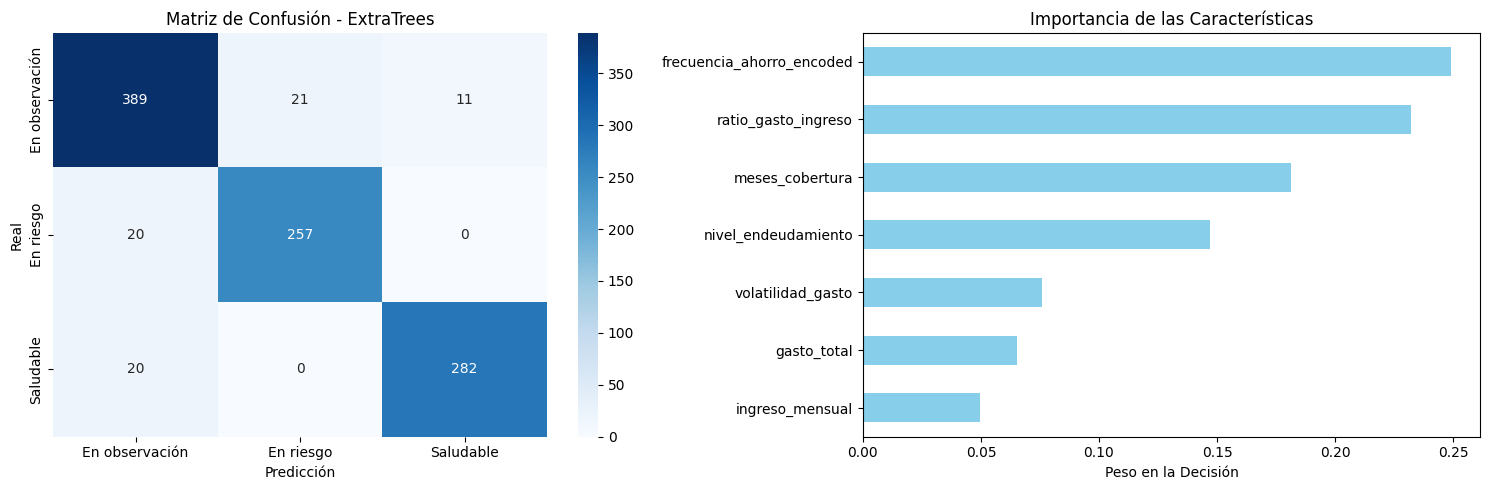

Modelo perfil conductual optimizado serializado en: modelos_y_preprocesadores/modelo_perfiles_conductual_optimo.pkl
¡La versión del modelo perfil conductual optimizado ha sido guardada exitosamente!
Modelo label encoder serializado en: modelos_y_preprocesadores/label_encoder_perfil_conductual.pkl
¡La versión del modelo label encodero ha sido guardada exitosamente!


In [ ]:
import os
import random
import joblib
import matplotlib.pyplot as plt
import numpy as np
import optuna
import pandas as pd
import seaborn as sns
from sklearn.ensemble import ExtraTreesClassifier, RandomForestClassifier
from sklearn.metrics import classification_report, confusion_matrix, f1_score
from sklearn.model_selection import StratifiedKFold, train_test_split
from sklearn.preprocessing import LabelEncoder

optuna.logging.set_verbosity(optuna.logging.WARNING)
SEED = 42


# 1. NUEVA FUNCIÓN GENERADORA: VOLATILIDAD CONDUCTUAL EXPLÍCITA
def generar_perfiles_conductuales(num_perfiles=5000, semilla=42):
    random.seed(semilla)
    np.random.seed(semilla)
    perfiles = []

    for _ in range(num_perfiles):
        # Variables Financieras Básicas
        ingreso = round(np.random.normal(3500, 1500))
        ingreso = max(800, min(ingreso, 9000))

        nivel_endeudamiento = round(
            max(0, min(np.random.normal(30, 15), 85)), 1
        )
        frecuencia_ahorro = random.choice(["Baja", "Media", "Alta"])
        ahorro_val = {"Baja": 0, "Media": 1, "Alta": 2}[frecuencia_ahorro]

        ratio_gasto = max(0.25, min(np.random.normal(0.75, 0.18), 1.3))
        gasto_total = round(ingreso * ratio_gasto, 2)

        # NUEVAS VARIABLES CONDUCTUALES (VISIBLES EN X)
        # Volatilidad en el patrón de gasto mensual (desviación porcentual)
        volatilidad_gasto = round(np.random.beta(a=2, b=5) * 0.45, 2)

        # Resiliencia: Meses de cobertura con fondo de emergencia según su hábito de ahorro
        base_meses = ahorro_val * 2.5
        meses_cobertura = round(
            max(0, np.random.normal(base_meses, 1.2)), 1
        )

        # LÓGICA DE RIESGO DETERMINÍSTICA SOBRE X (Sin ruido oculto)
        # El riesgo aumenta si el gasto es alto Y volátil, y disminuye con el colchón de ahorro
        vulnerabilidad_gasto = ratio_gasto * (1 + (volatilidad_gasto * 1.5))

        score_riesgo = (
            (nivel_endeudamiento * 0.45)
            + (vulnerabilidad_gasto * 45)
            - (ahorro_val * 8)
            - (meses_cobertura * 3.5)
        )

        # Clasificación con umbrales claros sobre el score conductual
        if score_riesgo >= 48:
            perfil = "En riesgo"
        elif score_riesgo >= 26:
            perfil = "En observación"
        else:
            perfil = "Saludable"

        perfiles.append(
            {
                "ingreso_mensual": ingreso,
                "nivel_endeudamiento": nivel_endeudamiento,
                "frecuencia_ahorro": frecuencia_ahorro,
                "gasto_total": gasto_total,
                "ratio_gasto_ingreso": round(ratio_gasto, 2),
                "volatilidad_gasto": volatilidad_gasto,
                "meses_cobertura": meses_cobertura,
                "perfil_financiero": perfil,
            }
        )

    return pd.DataFrame(perfiles)


# Generación del dataset conductual
df = generar_perfiles_conductuales(num_perfiles=5000, semilla=SEED)

# 2. PREPROCESAMIENTO Y MATRIZ X
mapa_ahorro = {"Baja": 0, "Media": 1, "Alta": 2}
df["frecuencia_ahorro_encoded"] = df["frecuencia_ahorro"].map(mapa_ahorro)

le_target = LabelEncoder()
df["perfil_riesgo_encoded"] = le_target.fit_transform(df["perfil_financiero"])

# Inclusión explícita de las nuevas variables conductuales en X
X = df[
    [
        "ingreso_mensual",
        "nivel_endeudamiento",
        "frecuencia_ahorro_encoded",
        "gasto_total",
        "ratio_gasto_ingreso",
        "volatilidad_gasto",
        "meses_cobertura",
    ]
]
y = df["perfil_riesgo_encoded"]

X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.20, random_state=SEED, stratify=y
)


# 3. AUTOML CON OPTUNA SOBRE EL DATASET CONDUCTUAL
def objetivo(trial):
    classifier_type = trial.suggest_categorical(
        "classifier", ["RandomForest", "ExtraTrees"]
    )

    if classifier_type == "RandomForest":
        params = {
            "n_estimators": trial.suggest_int("rf_n_estimators", 150, 400),
            "max_depth": trial.suggest_int("rf_max_depth", 8, 20),
            "min_samples_split": trial.suggest_int("rf_min_samples_split", 2, 8),
            "class_weight": "balanced",
            "random_state": SEED,
            "n_jobs": -1,
        }
        model_cls = RandomForestClassifier(**params)
    else:
        params = {
            "n_estimators": trial.suggest_int("et_n_estimators", 150, 400),
            "max_depth": trial.suggest_int("et_max_depth", 8, 20),
            "min_samples_split": trial.suggest_int("et_min_samples_split", 2, 8),
            "class_weight": "balanced",
            "random_state": SEED,
            "n_jobs": -1,
        }
        model_cls = ExtraTreesClassifier(**params)

    skf = StratifiedKFold(n_splits=5, shuffle=True, random_state=SEED)
    scores = []

    for train_idx, val_idx in skf.split(X_train, y_train):
        X_tr, y_tr = X_train.iloc[train_idx], y_train.iloc[train_idx]
        X_va, y_va = X_train.iloc[val_idx], y_train.iloc[val_idx]

        model_cls.fit(X_tr, y_tr)
        preds = model_cls.predict(X_va)
        scores.append(f1_score(y_va, preds, average="macro"))

    return np.mean(scores)

print("Optimizando modelos en el dataset con Volatilidad Conductual Explícita...")
study = optuna.create_study(direction="maximize")
study.optimize(objetivo, n_trials=30)

mejor_algoritmo = study.best_params["classifier"]
print(f"\n¡Optimización completada!")
print(f"Modelo Ganador: {mejor_algoritmo}")
print(f"F1-Score Macro en CV: {study.best_value:.4f}")

# 4. ENTRENAMIENTO FINAL Y EVALUACIÓN
if mejor_algoritmo == "RandomForest":
    params = {
        "n_estimators": study.best_params["rf_n_estimators"],
        "max_depth": study.best_params["rf_max_depth"],
        "min_samples_split": study.best_params["rf_min_samples_split"],
        "class_weight": "balanced",
        "random_state": SEED,
        "n_jobs": -1,
    }
    modelo_final = RandomForestClassifier(**params)
else:
    params = {
        "n_estimators": study.best_params["et_n_estimators"],
        "max_depth": study.best_params["et_max_depth"],
        "min_samples_split": study.best_params["et_min_samples_split"],
        "class_weight": "balanced",
        "random_state": SEED,
        "n_jobs": -1,
    }
    modelo_final = ExtraTreesClassifier(**params)

modelo_final.fit(X_train, y_train)

# ==============================================================================
# EVALUACIÓN Y DASHBOARD GRÁFICO (MATRIZ + FEATURE IMPORTANCE)
# ==============================================================================
y_pred = modelo_final.predict(X_test)

print("\n--- INFORME DE RENDIMIENTO REAL DEL MODELO CONDUCTUAL ---")
print(classification_report(y_test, y_pred, target_names=le_target.classes_))

# Crear un lienzo limpio con 2 subplots lado a lado
fig, axes = plt.subplots(1, 2, figsize=(15, 5))

# Subplot 1: Matriz de Confusión
sns.heatmap(
    confusion_matrix(y_test, y_pred),
    annot=True,
    fmt="d",
    cmap="Blues",
    xticklabels=le_target.classes_,
    yticklabels=le_target.classes_,
    ax=axes[0],
)
axes[0].set_title(f"Matriz de Confusión - {mejor_algoritmo}")
axes[0].set_xlabel("Predicción")
axes[0].set_ylabel("Real")

# Subplot 2: Importancia de Características (Feature Importance)
importancias = pd.Series(
    modelo_final.feature_importances_, index=X.columns
).sort_values()
importancias.plot(kind="barh", color="skyblue", ax=axes[1])
axes[1].set_title("Importancia de las Características")
axes[1].set_xlabel("Peso en la Decisión")

plt.tight_layout()
plt.show()

# Exportación de artefactos
output_dir = "modelos_y_preprocesadores"
os.makedirs(output_dir, exist_ok=True)

joblib.dump(modelo_final, os.path.join(output_dir, "modelo_perfiles_conductual_optimo.pkl"))
joblib.dump(le_target, os.path.join(output_dir, "label_encoder_perfil_conductual.pkl"))

print(f"Modelo perfil conductual optimizado serializado en: {os.path.join(output_dir, "modelo_perfiles_conductual_optimo.pkl")}")
print("¡La versión del modelo perfil conductual optimizado ha sido guardada exitosamente!")

print(f"Modelo label encoder serializado en: {os.path.join(output_dir, "label_encoder_perfil_conductual.pkl")}")
print("¡La versión del modelo label encodero ha sido guardada exitosamente!")